In [8]:
import numpy as np

## This project runs on tf(python 3.11.5)

to run this work you need to go open the entire code in vs code and use the specific  environment to run the project nicely.

In [9]:
import tensorflow as tf
print("TF version", tf.__version__)


TF version 2.13.0


In [10]:
import tensorflow_hub as hub
print("Tensorflow version ", hub.__version__)

Tensorflow version  0.14.0


In [11]:
import pandas as pd
label_csv= pd.read_csv (r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)/labels.csv")
print(label_csv.describe())
print(label_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     000bec180eb18c7604dcecc8fe0dba07  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [12]:
#pip install pandas scikit-learn matplotlib seaborn0

<Axes: xlabel='breed'>

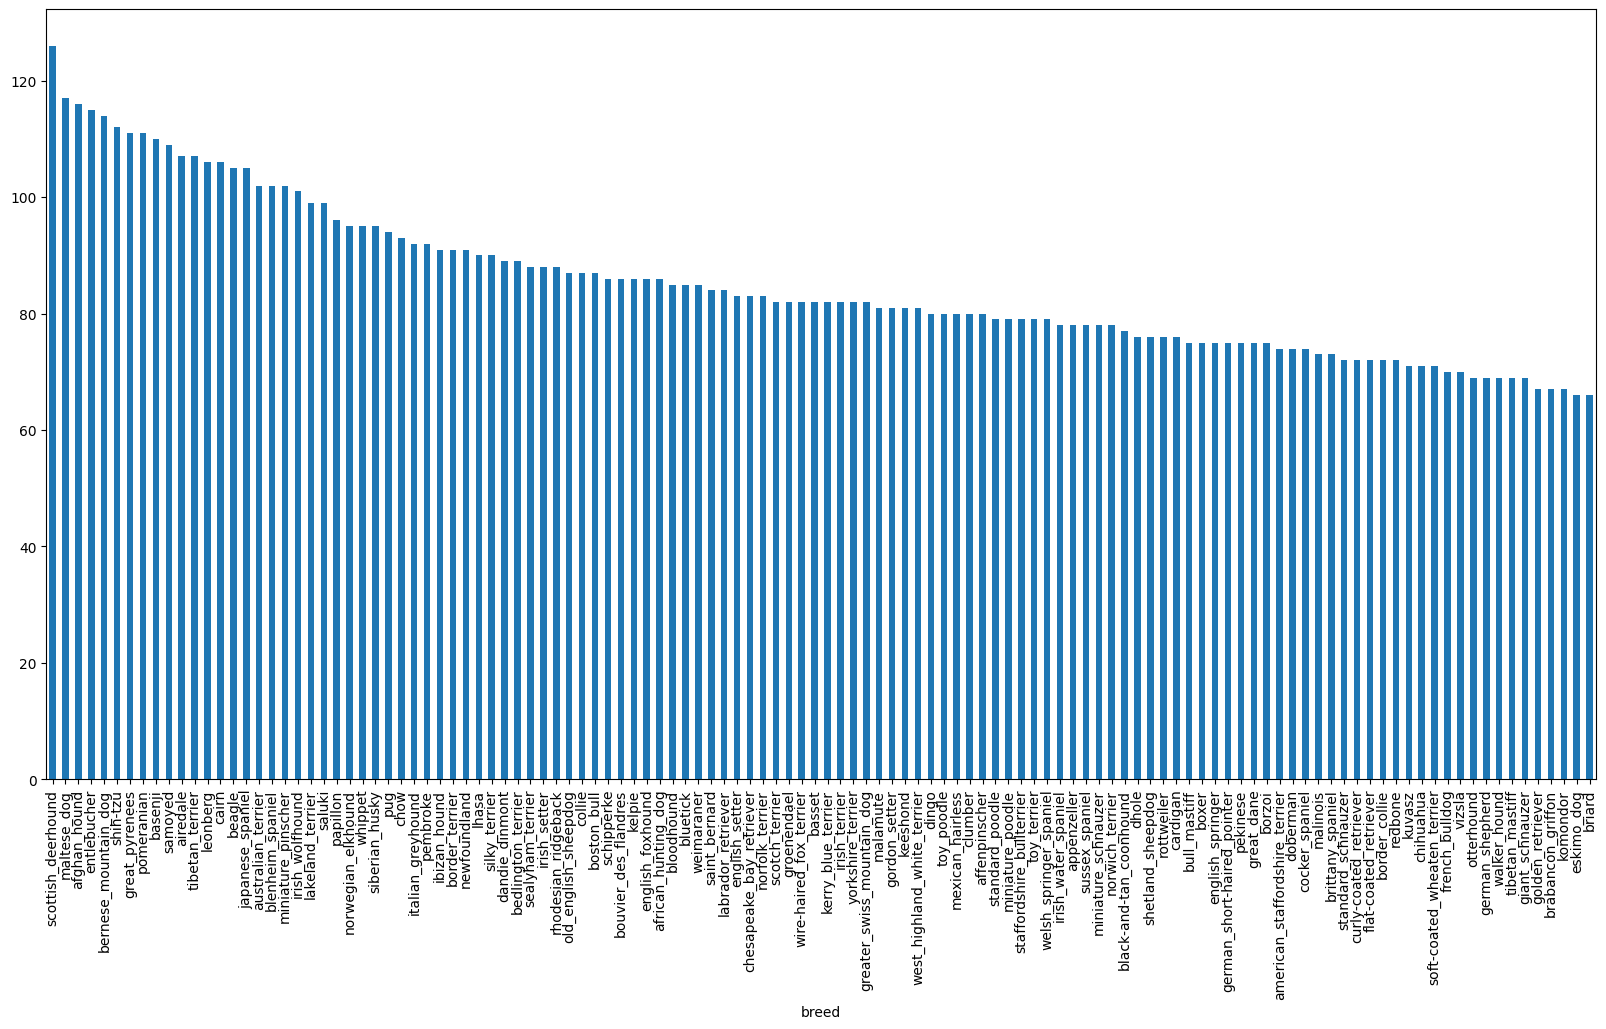

In [13]:
#how many images are there of each breeds?

label_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [14]:
import numpy as np

In [15]:
label_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


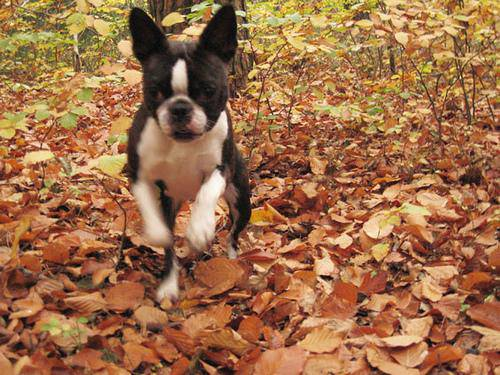

In [16]:

#let's view an image
from IPython.display import Image
Image(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\train\000bec180eb18c7604dcecc8fe0dba07.jpg")

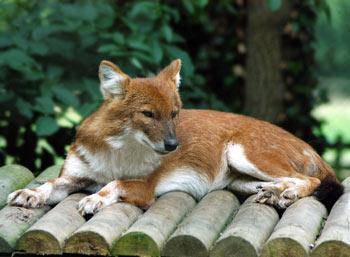

In [17]:
#let's view an image
from IPython.display import Image
Image(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\train\011e06760794850c40f23d6426c40774.jpg")

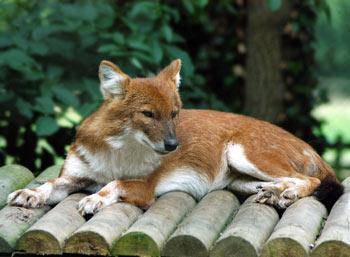

In [18]:
#let's view an image
from IPython.display import Image
Image(r"C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/011e06760794850c40f23d6426c40774.jpg")

In [19]:
# create pathnames for image id's
filename=[r"C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/" + fname + ".jpg" for fname in label_csv["id"]]

# check the first 10
filename[:10]

['C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'C:/Users/shruti s

In [20]:
#check whether the numbers of filename matches the number of actual image files

import os
if len(os.listdir(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\train"))== len(filename):
  print("Filenames match actual amount of files!!! proceed")
else :
  print("Not equal!!......check again")


Filenames match actual amount of files!!! proceed


In [21]:
# creating labels
import numpy as np
labels= label_csv["breed"]
labels= np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [22]:
#see if number of labels matches the number of filename
if(len(labels)==len(filename)):
  print("No.of labels matches no. of filename")
else:
  print("Does not matches")

No.of labels matches no. of filename


In [23]:
# find the unique label values
unique_breeds= np.unique(labels)
len(unique_breeds)

120

In [24]:
#Turn a single label into an array of booleans
print(labels[0])
labels[0]==unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [25]:
#Turn every labels into a boolean array
boolean_labels= [label==unique_breeds for label in labels]
boolean_labels[:2]


[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [26]:
len(boolean_labels)

10222

In [27]:
#  Example ::::    turning boolean array into intergers
print(labels[0])    #original label
print(np.where(unique_breeds==labels[0]))  #index where  label occurs
print(boolean_labels[0].argmax())      # index where label occur in boolean array

print(boolean_labels[0].astype(int))     # there will be a 1 where the sample label occur.


boston_bull
(array([19], dtype=int64),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [28]:
print(boolean_labels[2])      # index where label occur in boolean array

print(boolean_labels[2].astype(int))     # there will be a 1 where the sample label occur.

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [29]:
#setup x and y variables
x=filename
y=boolean_labels

In [30]:
#set number of images to use for experimenting
NUM_IMAGES= 1000 #@param{ type="slider", min:1000,max:10,000, step: 1000}

In [31]:
#let's split our data into train and validation sets

from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val= train_test_split(x[:NUM_IMAGES], y[:NUM_IMAGES],test_size=0.2, random_state=42)


In [32]:
#check
len(x_train), len(y_train),len(x_val),len(y_val)

(800, 800, 200, 200)

In [33]:
#let's have a geez at the training data
x_train[:5], y_train[:5]

(['C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/00bee065dcec471f26394855c5c2f3de.jpg',
  'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/0d2f9e12a2611d911d91a339074c8154.jpg',
  'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/1108e48ce3e2d7d7fb527ae6e40ab486.jpg',
  'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/0dc3196b4213a2733d7f4bdcd41699d3.jpg',
  'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/train/146fbfac6b5b1f0de83a5d0c1b473377.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, F

In [34]:
#convert image to numpy array

from matplotlib.pyplot import imread
image= imread(filename[42])
image.shape

(257, 350, 3)

In [35]:
#turn the images into tensors
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

# functions to preprocess

In [36]:
# define image size
IMG_SIZE= 224

# create a function for preprocessing image

def process_image (image_path, img_size= IMG_SIZE):
    #take an image file path and turn the image into tensors
    # read in an image file
    image= tf.io.read_file(image_path)
    #turn the image into numerical tensor with 3 color
    image= tf.image.decode_jpeg(image, channels=3)
    # convert the colour channles value from 0-255 to 0-1 value             // NORMALISATION
    image= tf.image.convert_image_dtype(image, tf.float32)
    # resize the image to our desired value(224,224)
    image= tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])
    return image    
    


In [37]:
tensor= tf.io.read_file(filename[26])
tensor

<tf.Tensor: shape=(), dtype=string, numpy=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\n\x07\x07\x08\x07\x06\n\x08\x08\x08\x0b\n\n\x0b\x0e\x18\x10\x0e\r\r\x0e\x1d\x15\x16\x11\x18#\x1f%$"\x1f"!&+7/&)4)!"0A149;>>>%.DIC<H7=>;\xff\xdb\x00C\x01\n\x0b\x0b\x0e\r\x0e\x1c\x10\x10\x1c;("(;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;\xff\xc0\x00\x11\x08\x01\xf4\x01w\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca

# Turning data into batches

In [38]:
#create a simple function to return a tuple(image,label)
def get_image_label(image_path, label):
    image= process_image(image_path)
    return image,label

In [39]:
#demo of the above cell
(process_image(x[42]), y[42])

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

In [40]:
#define the batch size, 32 is good start
BATCH_SIZE=32
# create a function to turn data into batches
def create_data_batches(x,y=None, batch_size= BATCH_SIZE, valid_data= False, test_data= False):
    if test_data:
        print("Creating tets data batches.....")
        data= tf.data.Dataset.from_tensor_slices((tf.constant(x)))
        data_batch= data.map(process_image).batch(BATCH_SIZE)
        return data_batch
    
    # if the data is a valid dataset, we don't need to shuffle it
    elif valid_data:
        print("creating validation data batches.........")
        data= tf.data.Dataset.from_tensor_slices((tf.constant(x), tf.constant(y)))
        data_batch= data.map(get_image_label).batch(BATCH_SIZE)
        return data_batch
    else:
        print("creating training data batches")
        data= tf.data.Dataset.from_tensor_slices((tf.constant(x), tf.constant(y)))
        #shuffling pathnames and labels before mapping image processor function is faster tham shuffle
        data= data.shuffle(buffer_size=len(x))
        #create (image,label) tuples (this also turns the image path into a preprocessed image)
        data= data.map(get_image_label)
        
        #turn the traning data into batches
        data_batch= data.batch(BATCH_SIZE)
    return data_batch

In [41]:
#create training and validation data batches
train_data=create_data_batches(x_train,y_train)
val_data= create_data_batches(x_val,y_val, valid_data= True)

creating training data batches
creating validation data batches.........


In [42]:
# check out the different attributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

# Visualizing data batches

In [43]:
import matplotlib.pyplot as plt

In [44]:
# create a function for viewing images ina data batches
def show_25_images(images, labels):
    #setup the figure
    plt.figure(figsize=(10,10))
    #loop through   25 for displaying 25 images
    for i in range(25):
        # create subplots(5 rows, 5 columns)
        ax=plt.subplot(5,5,i+1)
        #display an image
        plt.imshow(images(i))
        #add the image label as the title
        plt.title(unique_breeds[labels[i].argmax()])
        # turn the grid lines off
        plt.axis("off")
                                 

In [45]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [46]:
train_images, train_labels= next(train_data.as_numpy_iterator())
len(train_images), len(train_labels)

(32, 32)

TypeError: 'numpy.ndarray' object is not callable

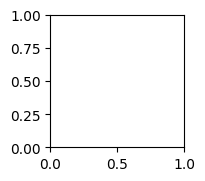

In [47]:
#lets visualize the data in training batches
show_25_images(train_images, train_labels)


In [48]:
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

# Building a model

before we build a model, there are a few things we need to define:
* the input shape(our images shape, int he form of tensors) to the model
* the output shape(image labels, in the form of tensors) of our model.
* the URL of the model we want to use

In [49]:
# setup input shape to the model
INPUT_SHAPE= [None, IMG_SIZE, IMG_SIZE,3]

In [50]:
#setup output shape
OUTPUT_SHAPE= len(unique_breeds)
OUTPUT_SHAPE

120

In [51]:
IMG_SIZE

224

In [52]:
# setup model URL from tensorflow hub
MODEL_URL="https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/5"

# difference between sequential and functional api

In [53]:
from tensorflow.keras.models import Sequential

In [54]:
# create a function which builds a keras model

def create_model(input_shape= INPUT_SHAPE, output_shape= OUTPUT_SHAPE, model_url= MODEL_URL):
    print("Building model with: ",MODEL_URL)
    
    #setup the model layers
    model= tf.keras.Sequential([
        hub.KerasLayer(MODEL_URL),
        tf.keras.layers.Dense(units= OUTPUT_SHAPE, activation= "softmax")])
    
    # compile the model
    model.compile(
        loss= tf.keras.losses.CategoricalCrossentropy(), 
        optimizer= tf.keras.optimizers.Adam(), 
        metrics=["accuracy"])
    
    # build the model
    model.build(INPUT_SHAPE)
    return model

In [65]:
model= create_model()
model.summary()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/5


ValueError: Trying to load a model of incompatible/unknown type. 'C:\Users\shruti sharma\AppData\Local\Temp\tfhub_modules\2c858e9d5fe42a1181c58c70d67244f7619f2ab2' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

# Summarising our model

In [56]:
# creating callbacks
#TensorBoard Callback
#load Tensorboard.notebook extension
%load_ext tensorboard 




In [57]:
import datetime
#create a function for tensorflow Board Callback
def create_tensorboard_callback():
    #create a log directory for storing tensorflow logs
    logdir=os.path.join(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\logs", 
                        datetime.datetime.now().strftime("%Y %m %d- %H %M %S"))
    return tf.keras.callbacks.TensorBoard(logdir)  

In [58]:
# if model runs for too long
#create early stopping call back

early_stopping= tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

# Training a Model

In [59]:
NUM_EPOCHS= 100 # @param{type:"slider", min:10, max=100, step:10}



In [60]:
#check to make sure we are still running on GPU
print("GPU", "available(YESS!!)" if tf.config.list_physical_devices("GPU") else "not available:")

GPU not available:


In [61]:
# Build a function to train and return a trained model
def train_model():
    # create a model
    model= create_model()
    
    #create new Tensorboard session everytime we train a model
    tensorboard= create_tensorboard_callback()
    
    #fit the model passing callbacks
    model.fit(x= train_data,
              epochs= NUM_EPOCHS,
              validation_data =val_data,
              validation_freq= 1,
              callbacks= [tensorboard, early_stopping])
    return model
              

In [62]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [63]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [64]:
model = train_model()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/5


ValueError: Trying to load a model of incompatible/unknown type. 'C:\Users\shruti sharma\AppData\Local\Temp\tfhub_modules\2c858e9d5fe42a1181c58c70d67244f7619f2ab2' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

In [ ]:
# checking tensorflow logs
%tensorboard --logdir C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\logs

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--inspect] [--version_tb]
                   [--tag TAG] [--event_file PATH] [--path_prefix PATH]
                   [--window_title TEXT] [--max_reload_threads COUNT]
                   [--reload_interval SECONDS] [--reload_task TYPE]
                   [--reload_multifile BOOL]
                   [--reload_multifile_inactive_secs SECONDS]
                   [--generic_data TYPE]
                   [--samples_per_plugin SAMPLES_PER_PLUGIN]
                   [-

# Evaluating predictions

In [ ]:
predictions= model.predict(val_data, verbose=1)
predictions

7/7 [==============================] - 6s 669ms/step


array([[5.14726737e-04, 4.35194641e-04, 4.00466670e-04, ...,
        4.17392526e-04, 2.80754393e-05, 5.12210792e-03],
       [2.82913446e-03, 9.74752358e-04, 3.31765115e-02, ...,
        2.44813738e-04, 5.50323725e-03, 1.33541063e-04],
       [8.90867886e-06, 3.42430758e-05, 1.45126498e-04, ...,
        1.73840908e-05, 1.24447848e-04, 3.63285035e-05],
       ...,
       [1.50051210e-05, 1.05474435e-04, 2.95232312e-04, ...,
        6.17971818e-05, 1.44681311e-04, 1.36928997e-04],
       [4.44482220e-03, 3.61262937e-04, 2.43759248e-04, ...,
        3.01932538e-04, 3.18707898e-05, 1.20673692e-02],
       [5.77345025e-04, 1.95259490e-05, 4.27396939e-04, ...,
        1.79272052e-02, 1.06458715e-03, 2.76461331e-04]], dtype=float32)

In [ ]:
predictions.shape

(200, 120)

In [ ]:
# first predictions
print(predictions)
print(f" Max value (probability of predictions):{np.max(predictions[0])}")
print(f"sum: {np.sum(predictions[0])}")
print(f"max index: {np.argmax(predictions[0])}")
print(f"predicted label: {unique_breeds[np.argmax(predictions[0])]}")

[[5.14726737e-04 4.35194641e-04 4.00466670e-04 ... 4.17392526e-04
  2.80754393e-05 5.12210792e-03]
 [2.82913446e-03 9.74752358e-04 3.31765115e-02 ... 2.44813738e-04
  5.50323725e-03 1.33541063e-04]
 [8.90867886e-06 3.42430758e-05 1.45126498e-04 ... 1.73840908e-05
  1.24447848e-04 3.63285035e-05]
 ...
 [1.50051210e-05 1.05474435e-04 2.95232312e-04 ... 6.17971818e-05
  1.44681311e-04 1.36928997e-04]
 [4.44482220e-03 3.61262937e-04 2.43759248e-04 ... 3.01932538e-04
  3.18707898e-05 1.20673692e-02]
 [5.77345025e-04 1.95259490e-05 4.27396939e-04 ... 1.79272052e-02
  1.06458715e-03 2.76461331e-04]]
 Max value (probability of predictions):0.4311925172805786
sum: 1.0
max index: 26
predicted label: cairn


In [ ]:
# turn the predictions possibilties into respective lables

def get_pred_label(prediction_probabilties):
    return unique_breeds[np.argmax(prediction_probabilties)]

In [ ]:
# get a predicted label based on an array of prediction possibilties

pred_label= get_pred_label(predictions[81])
pred_label

'dingo'

In [ ]:
# split element of dataset into multiple elements

images_ =[]
labels_ =[]
# loop through unbatched data
for image, label in val_data.unbatch().as_numpy_iterator():
    images_.append(image)
    labels_.append(labels)

In [ ]:
images_[0], labels[0]

(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

In [ ]:
# create a function to unbatch labels

def unbatchify(data):
    images=[]
    labels=[]
    #loop through unbatched data
    for image, label in data.unbatch().as_numpy_iterator():
        images.append(image)
        labels.append(unique_breeds[np.argmax(label)])
    return images, labels    

In [ ]:
# unbatchifying the validation data
val_images, val_labels= unbatchify(val_data)
val_images[0], val_labels[0]

(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

# Visualising Model Predictions

prediction_labels, validation_labels, validation_images

Will create a function which:
* takes an array of prediction probabilities, an array of truth labels and an array of images and an array of truth labels an array of images and an integers
* convert the prediction probabilities to prediction labels
* plot the predicted label, its predicted probabilities, the truth label and the target image on a single plot.

In [ ]:
def plot_pred(prediction_probabilities, labels, images, n=1):
    pred_prob, true_label, image= prediction_probabilities[n], labels[n], images[n]

    pred_label= get_pred_label(pred_prob)
    #plot images and remove ticks
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

    if pred_label== true_label:
        color="green"
    else:
        color="red"

    
    # change the plot title to be predicted, probability of prediction and truth label.
    plt.title("Actual :"+ true_label + "\n Predict: " + pred_label , fontsize=10, color= color) 
    #plt.title("{} {:2.0f}% {}".format(pred_label ,np.max(pred_prob)*100, true_label, color= "color"))
    pass    

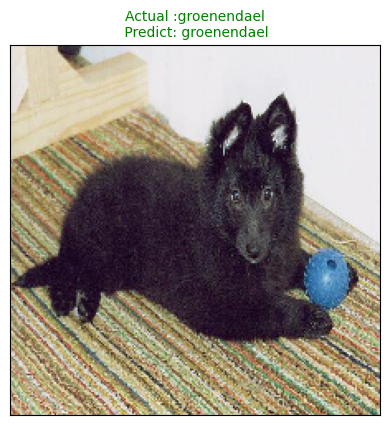

In [ ]:
plot_pred(prediction_probabilities= predictions, labels= val_labels, images= val_images, n=77)

## lets make a function to view our model's top 10 predictions:

 this function will:
 * take an input of prediction probabilities array and a ground truth array and an integer
 * find the predictions using "get_pred_label()"
* find the top 10:
    * prediction probabilities indexes
    * prediction probabilities values
    * predictions labels
* plot the top 10 prediction probability values and labels, coloring the true label green    


In [ ]:
def plot_pred_conf(prediction_probabilities, labels, n=1):
    pred_prob, true_label= prediction_probabilities[n], labels[n]

    #get the predicted label
    pred_label= get_pred_label(pred_prob)

    #find the top 10 prediction confidence indexes
    top_10_pred_indexes= pred_prob.argsort()[-10:][::-1]
    
    # finding the top 10 predictions values
    top_10_pred_values=pred_prob[top_10_pred_indexes]

    # find the top 10 predictions labels
    top_10_pred_labels= unique_breeds[top_10_pred_indexes]

    # setup plot
    top_plot= plt.bar(np.arange(len(top_10_pred_labels)), top_10_pred_values,color= "grey")
    plt.xticks(np.arange(len(top_10_pred_labels)),
    labels=top_10_pred_labels,
    rotation="vertical")

    # change the color
    if np.isin(true_label, top_10_pred_labels):
        top_plot[np.argmax(top_10_pred_labels== true_label)].set_color("green")
    else:
        color="red";
    pass    

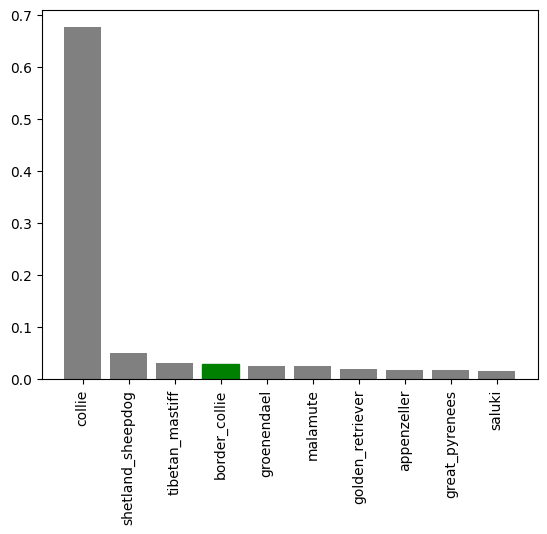

In [ ]:
plot_pred_conf(prediction_probabilities=predictions, labels= val_labels, n=9)

## Function to visualize and evaluate our model a lot

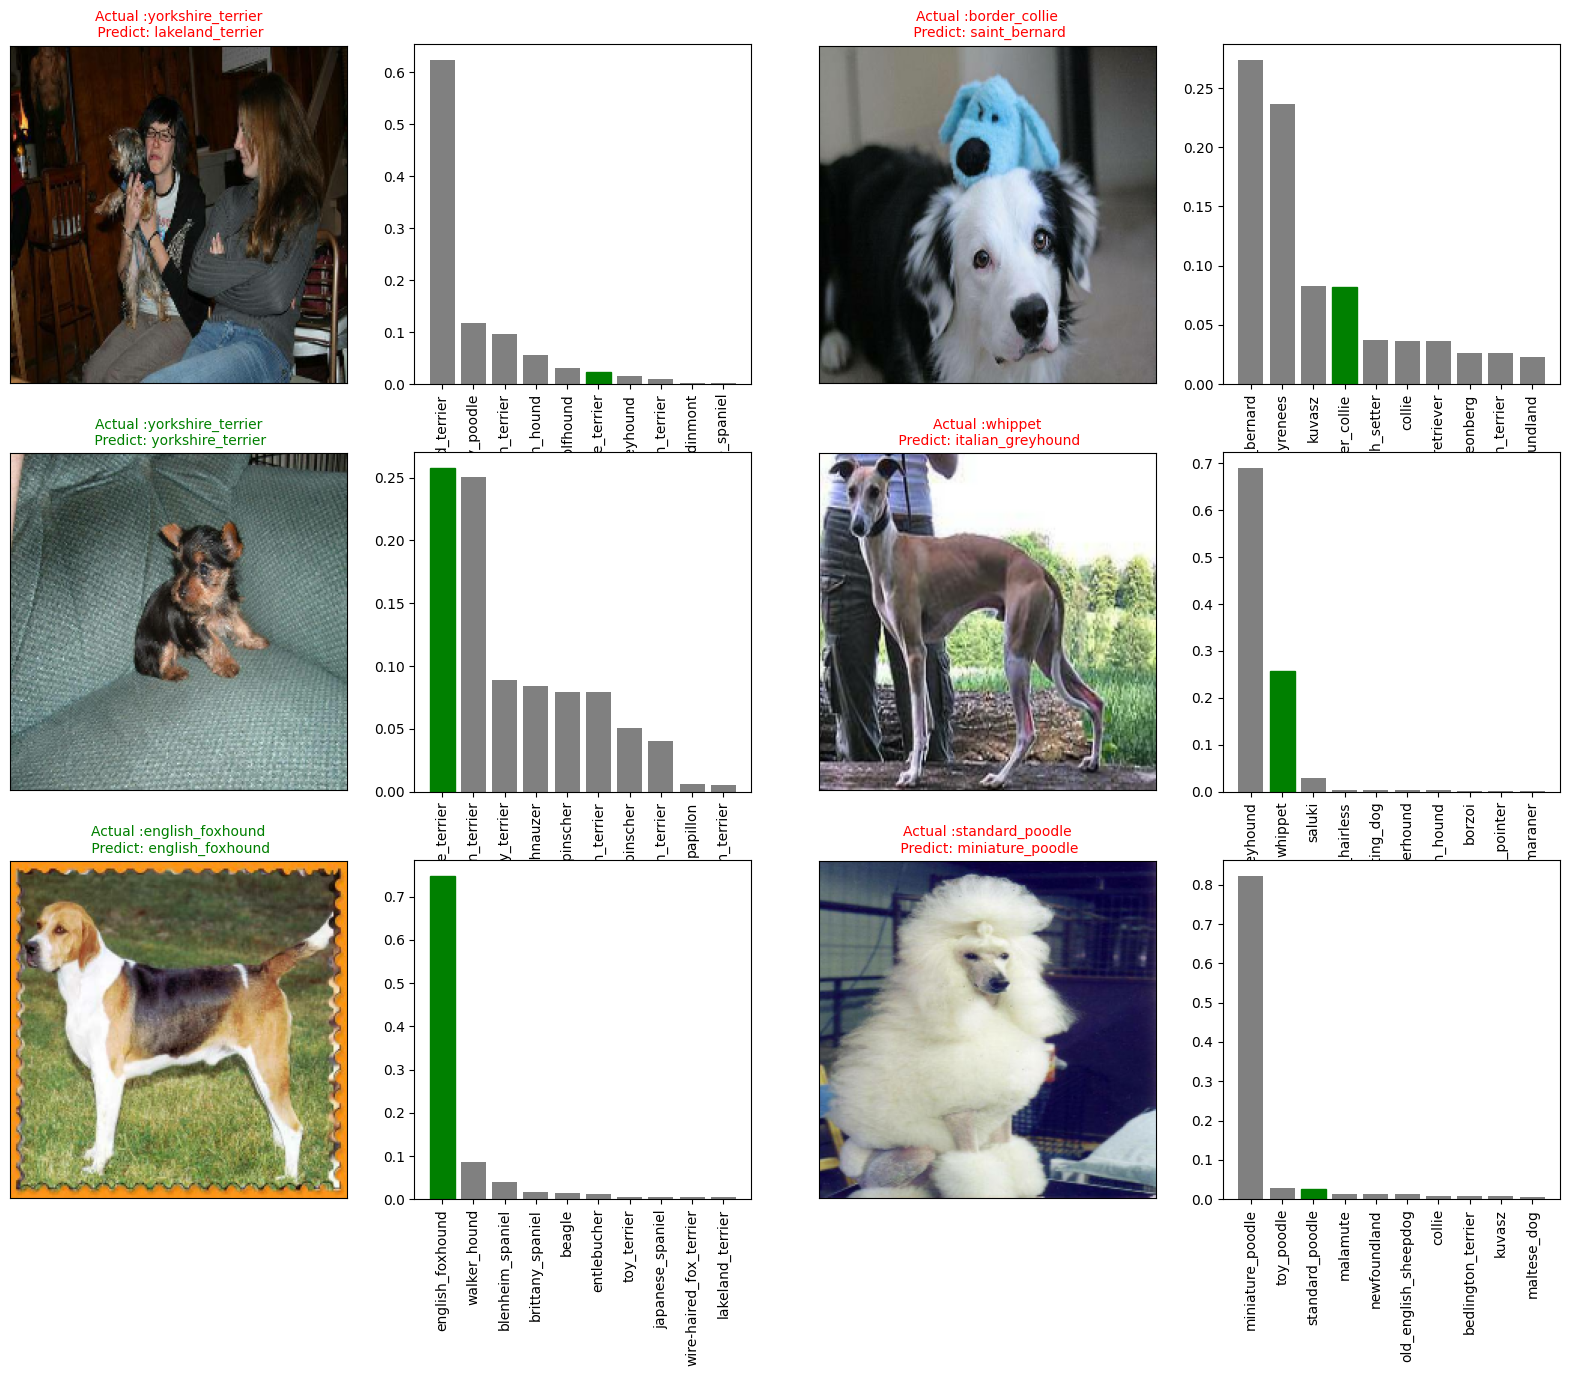

In [ ]:
# let's create out a few predictions and their different values

i_multiplier= 10
num_cols=2
num_rows=3
num_images= num_rows* num_cols
plt.figure(figsize= (10* num_cols, 5*num_rows))
for i in range (num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_pred(prediction_probabilities= predictions,
              labels= val_labels,
              images= val_images,
              n=i+i_multiplier)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_pred_conf(prediction_probabilities= predictions, labels= val_labels, n=i+i_multiplier)
   
plt.show()    

# Save and Load our Model

Create a function to save a model

In [ ]:
def save_model(model, suffix= None):
    modeldir= os.path.join("C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models", datetime.datetime.now().strftime("%m%d%Y- %H%I%p"))
    model_path= modeldir + "_" +suffix + ".h5"
    print(f"Saving model to: {model_path}....")     # save format of model
    model.save(model_path)
    return model_path                                                                                                                       

In [ ]:
# Create a function to load a trained model
def load_model(model_path):
    print(f"Loading saved model from :{model_path}")
    model= tf.keras.models.load_model(model_path, custom_objects={"KerasLayer" :hub.KerasLayer})
    return model

In [ ]:
# save our model trained on 1000 images
save_model(model, suffix="1000_images_mobilenetV2_Adam")

Saving model to: C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\07152025- 1111AM_1000_images_mobilenetV2_Adam.h5....


c:\Users\shruti sharma\Downloads\dog-breed-identification (1)\tf\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\\07152025- 1111AM_1000_images_mobilenetV2_Adam.h5'

In [ ]:
# load a model
load_1000_image_model= load_model('C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\\11152023- 1301PM_1000_images_mobilenetV2_Adam.h5')

Loading saved model from :C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\11152023- 1301PM_1000_images_mobilenetV2_Adam.h5


In [ ]:
# evaluate the pre saved model
model.evaluate(val_data)

7/7 [==============================] - 5s 736ms/step - loss: 1.3067 - accuracy: 0.6400


[1.3066954612731934, 0.6399999856948853]

In [ ]:
# Evaluate the loaded model
load_1000_image_model.evaluate(val_data)

7/7 [==============================] - 5s 662ms/step - loss: 1.2811 - accuracy: 0.6500


[1.2811295986175537, 0.6499999761581421]

# Training on Full Data

In [ ]:
full_data= create_data_batches(x,y)
full_data

creating training data batches


<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [ ]:
# create a model for full model
full_model= create_model()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/5


In [ ]:
# create full model callbacks

full_model_tensorboard= create_tensorboard_callback()
full_model_early_stopping=tf.keras.callbacks.EarlyStopping(monitor="accuracy",patience=3)

In [ ]:
# fit the full model
full_model.fit(x= full_data, epochs=NUM_EPOCHS, callbacks=[full_model_tensorboard, full_model_early_stopping])

Epoch 1/100
320/320 [==============================] - 246s 755ms/step - loss: 1.3276 - accuracy: 0.6741
Epoch 2/100
320/320 [==============================] - 216s 673ms/step - loss: 0.4019 - accuracy: 0.8802
Epoch 3/100
320/320 [==============================] - 209s 650ms/step - loss: 0.2358 - accuracy: 0.9361
Epoch 4/100
320/320 [==============================] - 198s 619ms/step - loss: 0.1557 - accuracy: 0.9616
Epoch 5/100
320/320 [==============================] - 193s 603ms/step - loss: 0.1043 - accuracy: 0.9803
Epoch 6/100
320/320 [==============================] - 202s 630ms/step - loss: 0.0779 - accuracy: 0.9860
Epoch 7/100
320/320 [==============================] - 201s 629ms/step - loss: 0.0585 - accuracy: 0.9912
Epoch 8/100
320/320 [==============================] - 185s 579ms/step - loss: 0.0456 - accuracy: 0.9940
Epoch 9/100
320/320 [==============================] - 162s 505ms/step - loss: 0.0377 - accuracy: 0.9951
Epoch 10/100
320/320 [==============================] -

In [ ]:
save_model(full_model, suffix="full_model_Adam")

Saving model to: C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\07152025- 1212PM_full_model_Adam.h5....


'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\\07152025- 1212PM_full_model_Adam.h5'

In [ ]:
loaded_full_model= load_model('C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\\11152023- 1402PM_full_model_Adam.h5')

NameError: name 'load_model' is not defined

# Making Predictions
* get the test image filenames
* convert the filenames into test data batches using 'create_data_batches()' and setting the 'test_data' parameter to "True"
* make a prediction array by passing the test batches to the predict() method called on our model.

In [ ]:
#load test image filenames
test_path= "C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/"
test_filenames= [test_path+ fname for fname in os.listdir(test_path)]
test_filenames[:10]

['C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/000621fb3cbb32d8935728e48679680e.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/00102ee9d8eb90812350685311fe5890.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/0012a730dfa437f5f3613fb75efcd4ce.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/001510bc8570bbeee98c8d80c8a95ec1.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/001a5f3114548acdefa3d4da05474c2e.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/00225dcd3e4d2410dd53239f95c0352f.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/002c2a3117c2193b4d26400ce431eebd.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/002c58d413a521ae8d1a5daeb35fc803.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/test/002f80396f1e3db687c5932d7978b196.jpg',
 'C:/Users/shruti sharma/Dow

In [ ]:
# create test data batches
test_data=create_data_batches(test_filenames, test_data= True)


Creating tets data batches.....


In [ ]:
test_data


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [ ]:
# making prediction on test data batch using loaded full model

test_predictions=loaded_full_model.predict(test_data, verbose=1)

324/324 [==============================] - 196s 602ms/step


In [ ]:
# save predictions (NumpyArray) to csv file to access later
np.savetxt(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\preds_array.csv", test_predictions, delimiter=",")

In [ ]:
#load the prediitons from csv file
test_predictions= np.loadtxt(r"C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\preds_array.csv", delimiter=",")

In [ ]:
test_predictions[:10]

array([[4.13374335e-11, 1.53776471e-11, 1.44277663e-14, ...,
        4.09462910e-13, 8.14386947e-10, 1.88266121e-11],
       [8.17923410e-06, 2.50151743e-06, 5.25777857e-08, ...,
        4.20075447e-10, 8.01013528e-07, 5.03406694e-09],
       [1.11684571e-10, 2.56933481e-06, 1.39481244e-07, ...,
        3.39915545e-07, 1.89126914e-09, 2.47536019e-10],
       ...,
       [3.54422021e-08, 6.21008744e-10, 6.79358028e-11, ...,
        1.34621524e-11, 2.61427234e-11, 2.25797311e-10],
       [6.55377003e-11, 2.42980769e-09, 3.66986719e-10, ...,
        1.24440749e-06, 9.55320179e-09, 8.43812659e-11],
       [1.51061297e-08, 6.47837270e-11, 9.53927076e-11, ...,
        8.04040862e-12, 2.44243764e-10, 7.96994541e-08]])

In [ ]:
test_predictions.shape

(10357, 120)

# Converting data set into csv format

In [ ]:
# create a panda dataframe with empty columns
preds_df= pd.DataFrame(columns=["id"]+list(unique_breeds))
preds_df.head(5)

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier


In [ ]:
#append the test image id's to predictions dataframe
test_ids= [os.path.splitext(path)[0] for path in os.listdir(test_path)]
preds_df["id"]= test_ids

In [ ]:
#add the predictions probabilities to each dog breed column 
preds_df[list(unique_breeds)]=test_predictions
preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,000621fb3cbb32d8935728e48679680e,4.133743e-11,1.537765e-11,1.442777e-14,1.296854e-13,4.377155e-13,1.815005e-11,1.138573e-15,5.285257e-13,7.582805e-13,...,1.174533e-12,4.853588e-13,8.994209e-14,6.813352e-14,4.407785e-13,1.623738e-12,1.344920e-12,4.094629e-13,8.143869e-10,1.882661e-11
1,00102ee9d8eb90812350685311fe5890,8.179234e-06,2.501517e-06,5.257779e-08,2.652459e-08,4.502083e-06,2.772230e-08,2.277936e-06,2.809821e-06,1.009637e-07,...,2.002090e-08,1.940539e-06,2.574670e-08,5.198145e-06,9.125960e-08,2.853706e-07,5.077604e-04,4.200754e-10,8.010135e-07,5.034067e-09
2,0012a730dfa437f5f3613fb75efcd4ce,1.116846e-10,2.569335e-06,1.394812e-07,2.376710e-10,1.157820e-09,2.489980e-08,8.449502e-11,1.351839e-11,3.349508e-09,...,4.216264e-11,2.586236e-10,3.836779e-07,3.069861e-06,1.296234e-07,9.760323e-08,1.089562e-11,3.399155e-07,1.891269e-09,2.475360e-10
3,001510bc8570bbeee98c8d80c8a95ec1,9.930875e-06,1.199000e-07,2.190319e-06,5.932236e-06,1.893490e-05,4.151353e-06,2.348879e-10,1.646185e-08,9.404878e-07,...,1.254794e-06,7.309735e-10,6.801491e-06,9.245083e-09,6.144553e-06,9.002115e-09,3.417063e-14,1.875259e-03,5.487776e-10,7.086327e-06
4,001a5f3114548acdefa3d4da05474c2e,5.578244e-05,2.436787e-05,3.963875e-09,9.308730e-10,1.700026e-09,4.219180e-11,9.731101e-10,7.214213e-09,2.063859e-08,...,2.026721e-07,6.092272e-11,5.471253e-11,1.757120e-10,8.144485e-10,8.095390e-10,3.044514e-11,2.771035e-08,1.362582e-09,2.660593e-07


In [ ]:
preds_df.to_csv("C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/model_for_submission.csv ", index= False)

# Making prediction on custom inputs

* Get the filepaths of our own images
* Turn the filepaths into data batches using "create_data_batches()" and set the test_data to True
* Pass the custom image data to our model "predict" model
* Convert the predicted output to predictions labels.
* compare the predicted labels to custom images.

In [ ]:
custom_path="C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/"
custom_image_path= [custom_path + fname for fname in os.listdir(custom_path)]
custom_image_path

['C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/dog1.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/dog2.jpg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/p3.jpeg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/p4.jpeg',
 'C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/DogPhotos/p5.jpeg']

In [ ]:
# turn custom images into datset batches

custom_data= create_data_batches(custom_image_path, test_data= True)
custom_data

Creating tets data batches.....


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [ ]:
# Make predictions on the custom data
custom_preds= loaded_full_model.predict(custom_data)
#custom_preds.shape

1/1 [==============================] - 0s 145ms/step


In [ ]:
# Get custom image predictions labels
custom_preds_labels= [get_pred_label(custom_preds[i])
                      for i in range( len(custom_preds))]
custom_preds_labels

['german_shepherd',
 'labrador_retriever',
 'maltese_dog',
 'chihuahua',
 'australian_terrier']

In [ ]:
custom_images= []
# loop through unbatched data
for image in custom_data.unbatch().as_numpy_iterator():
    custom_images.append(image)

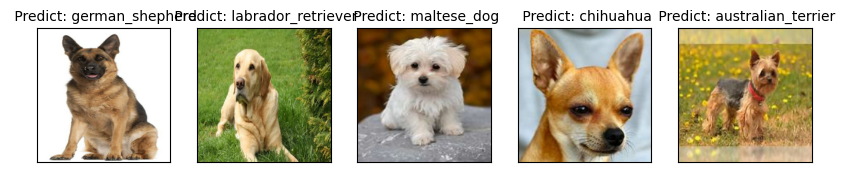

In [ ]:
plt.figure(figsize=(10,10))
for i, image in enumerate(custom_images):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    
    plt.title(" Predict: "+ custom_preds_labels[i], fontsize=10)
    plt.imshow(image)
    

# Code that links dog breed to css and html

In [ ]:
pip list

Package                      Version
---------------------------- ------------
absl-py                      1.4.0
altair                       5.5.0
asttokens                    2.4.0
astunparse                   1.6.3
attrs                        24.3.0
backcall                     0.2.0
blinker                      1.7.0
cachetools                   5.3.1
certifi                      2023.7.22
charset-normalizer           3.2.0
click                        8.1.7
colorama                     0.4.6
comm                         0.1.4
contourpy                    1.1.1
cycler                       0.11.0
debugpy                      1.8.0
decorator                    5.1.1
executing                    1.2.0
Flask                        3.0.0
flatbuffers                  23.5.26
fonttools                    4.42.1
gast                         0.4.0
gitdb                        4.0.11
GitPython                    3.1.43
google-auth                  2.23.0
google-auth-oauthlib         1.0.0

In [ ]:
from flask import Flask, flash, request, redirect, url_for, render_template
import urllib.request
import os
from werkzeug.utils import secure_filename
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing.image import img_to_array, load_img 

app= Flask(__name__)
UPLOAD_FOLDER= 'static/uploads'
app.secret_key= "secret key"
app.config['UPLOAD_FOLDER']= UPLOAD_FOLDER
app.config['MAX_CONTENT_LENGTH']= 16* 1024*1024

ALLOWED_EXTENSIONS= set(['png', 'jpg','jpeg','gif'])

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.',1)[1].lower() in ALLOWED_EXTENSIONS


@app.route('/')
def home():
    return render_template('start.html')


In [ ]:

@app.route('/', methods=['POST'])
def upload_image():
    if 'file' not in request.files:
        flash('No file part')
        return redirect(request.url)
    file= request.files['file']
    if file.filename=='':
        flash("NO image selected for uploading")
        return redirect(request.url)
    
    if file and allowed_file(file.filename):
        filename= secure_filename(file.filename)
        file.save(os.path.join(app.config['UPLOAD_FOLDER'], filename))
        #print('upload_image filename: '+filename)
        fullpaths=[r'C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\static\uploads\{}'.format(filename)]
        # print(fullpaths)

        img_data= np.array([img_to_array(load_img(img, target_size=(299,299))) for img in fullpaths])
        x_test1= img_data/255.
        test_predictions= model.predict(x_test1)
        predictions= le.classes_[np.argmax(test_predictions, axis=1)]
        # print(predictions[0])
        name= predictions[0].upper().replace("_"," ")
        return render_template('result.html',prediction= name, src="https://simple.wikipedia.org/wiki/"+predictions[0])



In [ ]:
if __name__=="__main__":
    app.run()        

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
from tensorflow.keras.models import load_model


In [ ]:
model = load_model('C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models\07152025- 1212PM_full_model_Adam.h5')

OSError: No file or directory found at C:/Users/shruti sharma/Downloads/dog-breed-identification (1)/models952025- 1212PM_full_model_Adam.h5

In [ ]:
from tensorflow.keras.models import load_model


In [ ]:
model = load_model(r'C:\Users\shruti sharma\Downloads\dog-breed-identification (1)\app.py\01142024- 1402PM_full_model_Adam.h5')


ValueError: Unknown layer: 'KerasLayer'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.